<a href="https://colab.research.google.com/github/ankit-kr6/LEARNING-ML/blob/main/video_53.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

In [40]:
x=6*np.random.rand(200,1)-3
y=0.8*x**2+x+0.9+np.random.randn(200,1)
# y=0.8x^2+0.x+2

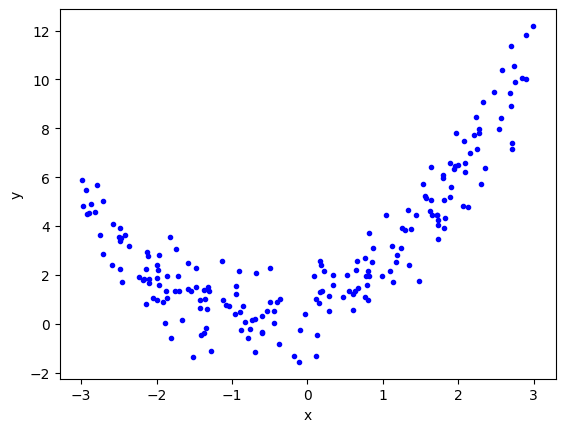

In [41]:
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [43]:
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(r2_score(y_test,y_pred))

0.036750547401607436


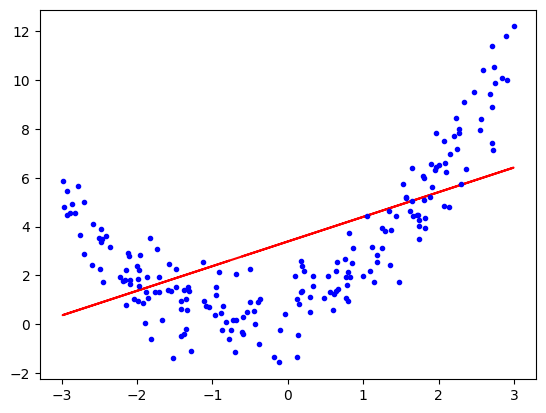

In [44]:
plt.plot(x_train,lr.predict(x_train),'r-')
plt.plot(x,y,'b.')
plt.show()

In [45]:
# applying polynomial linear regression
poly=PolynomialFeatures(degree=2,include_bias=True)
x_train_trans=poly.fit_transform(x_train)
x_test_trans=poly.transform(x_test)

In [46]:
print(x_train[0])
print(x_train_trans[0])

[-0.78530673]
[ 1.         -0.78530673  0.61670666]


In [47]:
lr=LinearRegression()
lr.fit(x_train_trans,y_train)
y_pred=lr.predict(x_test_trans)
print(r2_score(y_test,y_pred))

0.8563514036108978


In [48]:
print(lr.coef_)
print(lr.intercept_)

[[0.         1.05493911 0.82198102]]
[0.74714431]


In [49]:
x_new=np.linspace(-3,3,200).reshape(200,1)
x_new_poly=poly.transform(x_new)
y_new=lr.predict(x_new_poly)

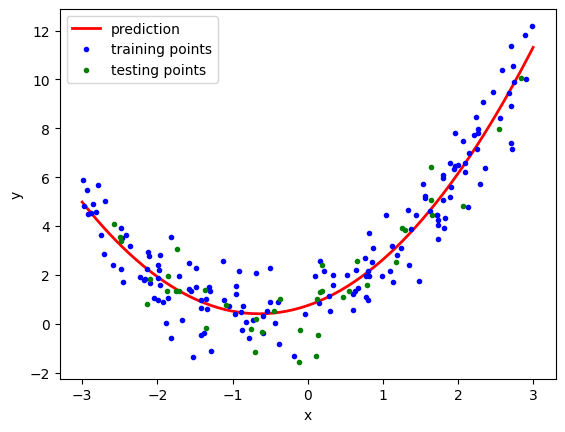

In [50]:
plt.plot(x_new,y_new,"r-",linewidth=2,label="prediction")
plt.plot(x_train,y_train,"b.",label="training points")
plt.plot(x_test,y_test,"g.",label="testing points")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()